# Regime-Based Trading Strategy Backtest

**Date**: 2026-04-03 | **Notebook 06** in the BTC Volatility Regimes series

**Objective**: Use Markov-Switching regime probabilities to dynamically adjust BTC exposure, reducing risk during turbulent regimes while capturing upside during calm periods.

**Core idea**: The 2-state MS model (from Notebook 03) gives us smoothed probabilities of being in a high-volatility regime at each point in time. We use these probabilities as a signal to scale portfolio weight between 0 (cash) and 1 (fully invested in BTC). The hypothesis is that avoiding large drawdowns during turbulent regimes improves risk-adjusted returns, even if raw cumulative returns may be lower.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Add src/ to path for data_loader
sys.path.insert(0, str(Path("..") / "src"))
from data_loader import load_from_csv, get_btc_returns

# Plot style
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
sns.set_palette("colorblind")

%matplotlib inline

## Part 1: Data Loading & Regime Detection

Load BTC log returns and fit a 2-regime Markov-Switching model with switching variance. Extract smoothed probabilities of being in the turbulent (high-volatility) regime.

In [2]:
# Load data
df = load_from_csv()
btc_ret = df["dln_btc"].dropna()  # Raw log returns (scale=1)

print(f"BTC returns: {len(btc_ret)} observations")
print(f"Date range: {btc_ret.index.min().date()} to {btc_ret.index.max().date()}")
print(f"Mean: {btc_ret.mean():.6f}, Std: {btc_ret.std():.4f}")

BTC returns: 4054 observations
Date range: 2015-01-05 to 2026-02-09
Mean: 0.001377, Std: 0.0354


In [3]:
# Fit 2-regime Markov-Switching model (switching mean + variance)
ms_model = MarkovRegression(
    btc_ret,
    k_regimes=2,
    switching_variance=True,
)
ms_result = ms_model.fit(disp=False)
print(ms_result.summary())

/opt/homebrew/Caskroom/miniconda/base/envs/quant/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                dln_btc   No. Observations:                 4054
Model:               MarkovRegression   Log Likelihood                8488.568
Date:                Fri, 03 Apr 2026   AIC                         -16965.137
Time:                        23:09:36   BIC                         -16927.292
Sample:                    01-05-2015   HQIC                        -16951.731
                         - 02-09-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.000      4.104      0.000       0.001       0.002
sigma2         0.0003   1.87e-05     14.925      0.0

In [4]:
# Extract smoothed probabilities
# Ensure regime 0 = calm (lower variance), regime 1 = turbulent (higher variance)
ms_proba = ms_result.smoothed_marginal_probabilities

# Check which regime has higher variance
regime_0_mask = ms_proba.iloc[:, 0] > 0.5
vol_0 = btc_ret[regime_0_mask].std()
vol_1 = btc_ret[~regime_0_mask].std()

if vol_0 > vol_1:
    # Regime 0 is actually turbulent -> swap
    prob_turbulent = ms_proba.iloc[:, 0]
    print("Swapped regimes: original regime 0 had higher vol")
else:
    prob_turbulent = ms_proba.iloc[:, 1]
    print("Regime labeling OK: regime 1 is turbulent")

prob_turbulent.name = "prob_turbulent"

print(f"\nCalm regime vol:      {min(vol_0, vol_1):.4f}")
print(f"Turbulent regime vol: {max(vol_0, vol_1):.4f}")
print(f"Vol ratio:            {max(vol_0, vol_1) / min(vol_0, vol_1):.1f}x")
print(f"\nMean P(turbulent): {prob_turbulent.mean():.3f}")
print(f"Days in turbulent regime (P > 0.5): {(prob_turbulent > 0.5).sum()} "
      f"({(prob_turbulent > 0.5).mean():.1%})")

Regime labeling OK: regime 1 is turbulent

Calm regime vol:      0.0159
Turbulent regime vol: 0.0578
Vol ratio:            3.6x

Mean P(turbulent): 0.363
Days in turbulent regime (P > 0.5): 1320 (32.6%)


## Part 2: Strategy Definition

We compare four strategies:

| Strategy | Weight Rule | Rationale |
|----------|------------|----------|
| **Buy-and-Hold** | $w_t = 1.0$ always | Baseline |
| **Regime-Switch** | $w_t = 1$ if $P(\text{turb})_t \leq 0.5$, else $0$ | Binary switch at 50% threshold |
| **Scaled** | $w_t = 1 - P(\text{turb})_t$ | Linear scaling by turbulence probability |
| **Threshold-0.7** | $w_t = 1$ if $P(\text{turb})_t \leq 0.7$, else $0$ | More conservative -- only exit at high conviction |

**Critical**: We use the **lagged** signal to avoid look-ahead bias. The signal at time $t$ determines the weight applied to the return at time $t+1$.

$$r_{\text{strategy}, t+1} = w_t \times r_{\text{BTC}, t+1}$$

In [5]:
# Align signal and returns
# Signal at t -> applied to return at t+1
# Use shift(1) on the signal so that signal_t aligns with return_{t+1}

signal = prob_turbulent.reindex(btc_ret.index)  # Align indices

# Lagged signal: shift signal forward by 1 day
# signal_lagged[t] = prob_turbulent[t-1], so weight at t is based on yesterday's signal
signal_lagged = signal.shift(1)

# Drop the first row (NaN from shift)
valid = signal_lagged.dropna().index
ret = btc_ret.loc[valid]
sig = signal_lagged.loc[valid]

# Compute weights for each strategy
weights = pd.DataFrame(index=valid)
weights["Buy-and-Hold"]   = 1.0
weights["Regime-Switch"]  = (sig <= 0.5).astype(float)
weights["Scaled"]         = 1.0 - sig
weights["Threshold-0.7"]  = (sig <= 0.7).astype(float)

# Compute strategy returns (log returns: weight * return is valid for log returns
# when weight is 0 or 1; for fractional weights this is an approximation)
strategy_returns = weights.multiply(ret, axis=0)

print("Strategy weight summary:")
print(weights.describe().round(3))
print(f"\nDays in sample: {len(ret)}")

Strategy weight summary:
       Buy-and-Hold  Regime-Switch    Scaled  Threshold-0.7
count        4053.0       4053.000  4053.000       4053.000
mean            1.0          0.674     0.637          0.750
std             0.0          0.469     0.364          0.433
min             1.0          0.000    -0.000          0.000
25%             1.0          0.000     0.301          1.000
50%             1.0          1.000     0.807          1.000
75%             1.0          1.000     0.958          1.000
max             1.0          1.000     0.986          1.000

Days in sample: 4053


## Part 3: Performance Metrics

Compute standard portfolio performance metrics for each strategy.

In [6]:
def compute_performance(returns: pd.Series) -> dict:
    """Compute portfolio performance metrics from a daily log return series."""
    # Cumulative wealth (log returns are additive)
    cum_wealth = np.exp(returns.cumsum())
    
    # Cumulative return
    cum_return = cum_wealth.iloc[-1] / cum_wealth.iloc[0] - 1
    
    # Annualized return (geometric)
    n_days = len(returns)
    total_return = cum_wealth.iloc[-1] / cum_wealth.iloc[0]
    ann_return = total_return ** (365 / n_days) - 1
    
    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(365)
    
    # Sharpe ratio (rf = 0 for simplicity)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    
    # Max drawdown
    running_max = cum_wealth.cummax()
    drawdown = cum_wealth / running_max - 1
    max_dd = drawdown.min()
    
    # Calmar ratio
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    
    # % time in market (non-zero returns)
    pct_in_market = (returns != 0).mean()
    
    return {
        "Cumulative Return": f"{cum_return:.1%}",
        "Ann. Return": f"{ann_return:.1%}",
        "Ann. Volatility": f"{ann_vol:.1%}",
        "Sharpe Ratio": f"{sharpe:.3f}",
        "Max Drawdown": f"{max_dd:.1%}",
        "Calmar Ratio": f"{calmar:.3f}",
        "% Time in Market": f"{pct_in_market:.1%}",
    }

In [7]:
# Compute performance for all strategies
perf_data = {}
for col in strategy_returns.columns:
    perf_data[col] = compute_performance(strategy_returns[col])

perf_table = pd.DataFrame(perf_data)
print("=" * 80)
print("STRATEGY PERFORMANCE COMPARISON")
print("=" * 80)
perf_table

STRATEGY PERFORMANCE COMPARISON


,Buy-and-Hold,Regime-Switch,Scaled,Threshold-0.7
Cumulative Return,24401.6%,2885.9%,3093.8%,4129.8%
Ann. Return,64.1%,35.8%,36.6%,40.1%
Ann. Volatility,67.7%,35.2%,29.1%,43.2%
Sharpe Ratio,0.947,1.016,1.259,0.929
Max Drawdown,-83.4%,-41.4%,-41.9%,-55.3%
Calmar Ratio,0.769,0.864,0.873,0.725
% Time in Market,100.0%,67.4%,100.0%,75.0%


## Part 4: Visualization

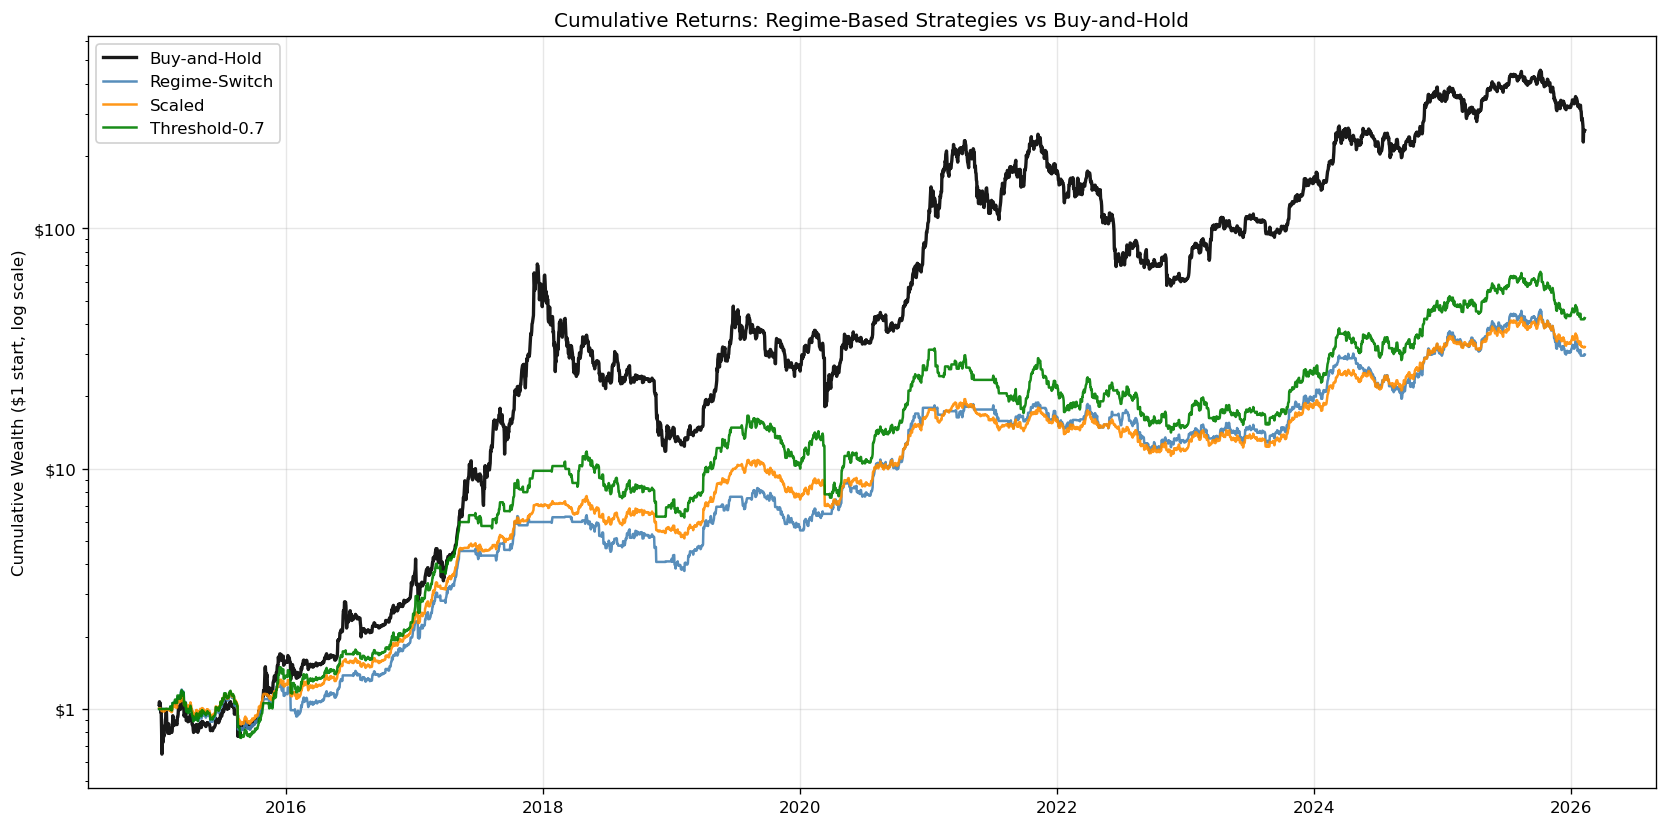

In [8]:
# Plot 1: Cumulative wealth curves (log scale, start at $1)
fig, ax = plt.subplots(figsize=(14, 7))

colors = {"Buy-and-Hold": "black", "Regime-Switch": "steelblue",
          "Scaled": "darkorange", "Threshold-0.7": "green"}

for col in strategy_returns.columns:
    cum_wealth = np.exp(strategy_returns[col].cumsum())
    ax.plot(cum_wealth.index, cum_wealth, label=col,
            color=colors[col], linewidth=1.5 if col != "Buy-and-Hold" else 2,
            alpha=0.9)

ax.set_yscale("log")
ax.set_ylabel("Cumulative Wealth ($1 start, log scale)")
ax.set_title("Cumulative Returns: Regime-Based Strategies vs Buy-and-Hold")
ax.legend(loc="upper left", framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../figures/06_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()

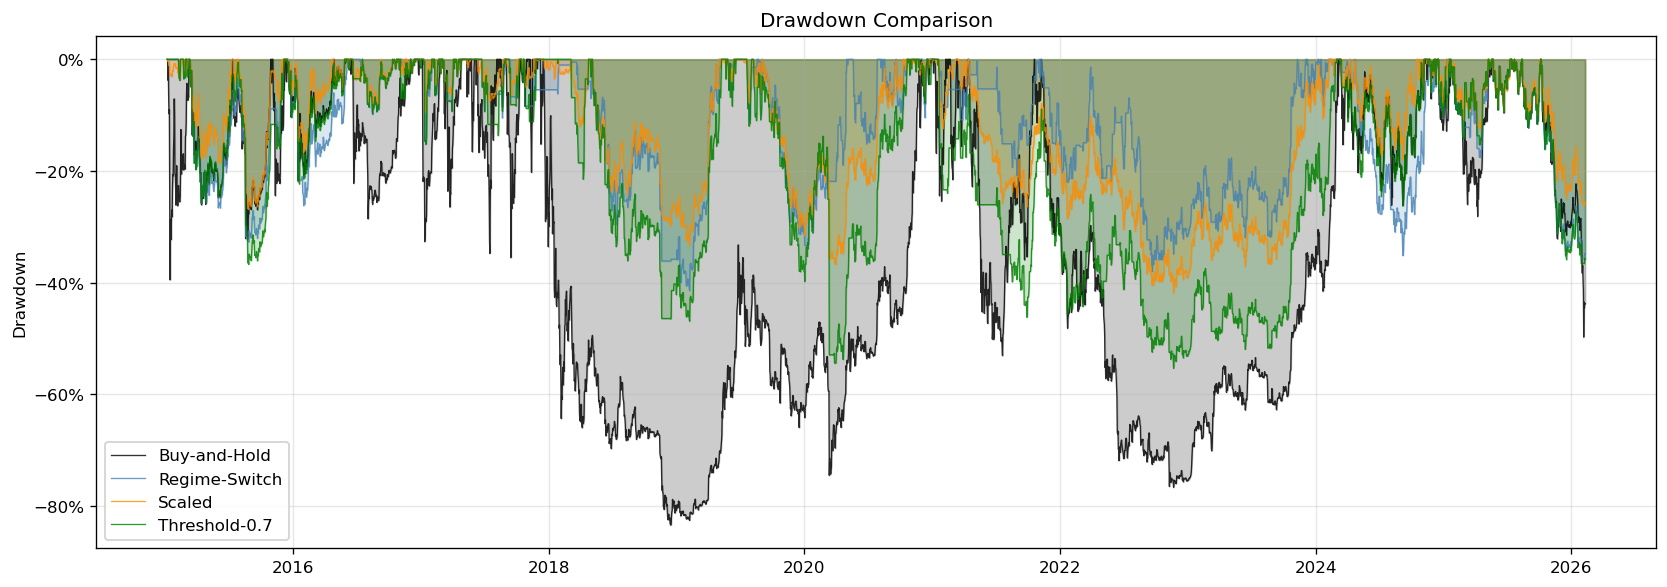

In [9]:
# Plot 2: Drawdown chart
fig, ax = plt.subplots(figsize=(14, 5))

for col in strategy_returns.columns:
    cum_wealth = np.exp(strategy_returns[col].cumsum())
    drawdown = cum_wealth / cum_wealth.cummax() - 1
    ax.fill_between(drawdown.index, drawdown, alpha=0.2, color=colors[col])
    ax.plot(drawdown.index, drawdown, label=col, color=colors[col],
            linewidth=0.8, alpha=0.8)

ax.set_ylabel("Drawdown")
ax.set_title("Drawdown Comparison")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="lower left", framealpha=0.9)

plt.tight_layout()
plt.savefig("../figures/06_drawdowns.png", dpi=150, bbox_inches="tight")
plt.show()

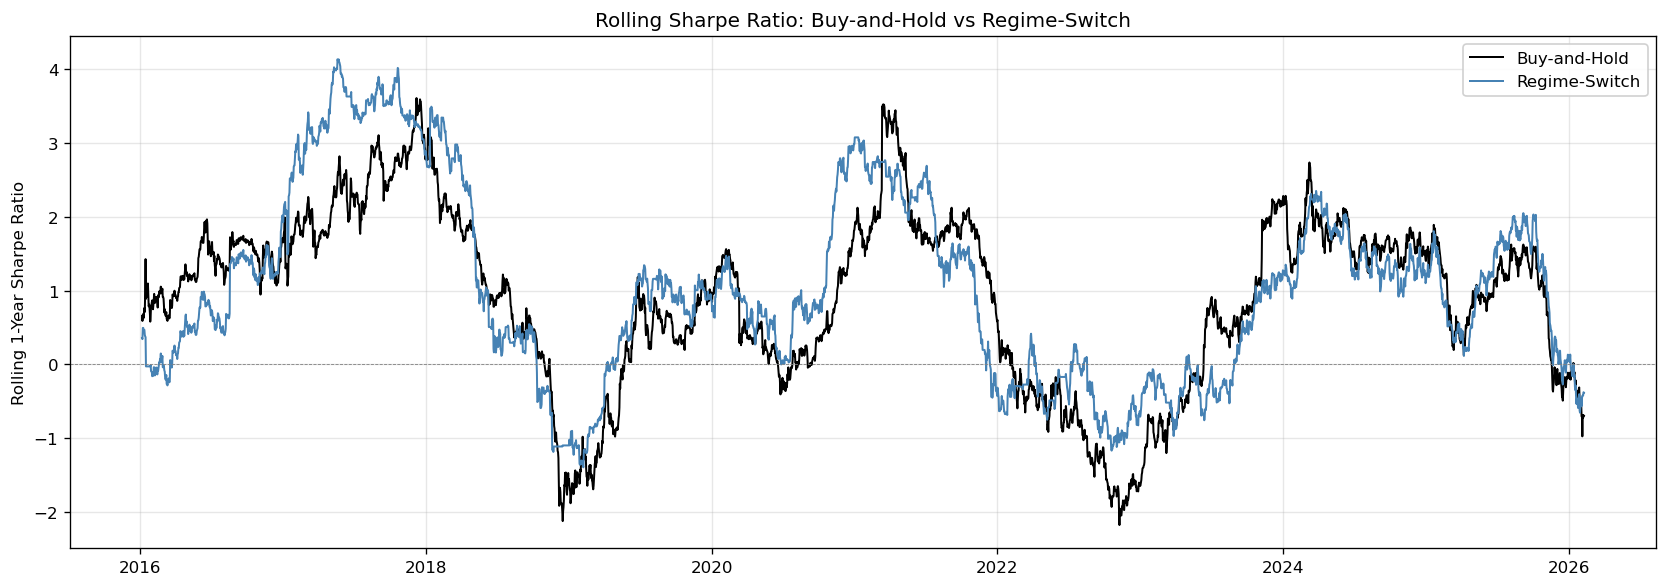

In [10]:
# Plot 3: Rolling 1-year (365-day) Sharpe ratio -- BnH vs Regime-Switch
window = 365

fig, ax = plt.subplots(figsize=(14, 5))

for col in ["Buy-and-Hold", "Regime-Switch"]:
    rolling_mean = strategy_returns[col].rolling(window).mean() * 365
    rolling_vol = strategy_returns[col].rolling(window).std() * np.sqrt(365)
    rolling_sharpe = rolling_mean / rolling_vol
    ax.plot(rolling_sharpe.index, rolling_sharpe, label=col,
            color=colors[col], linewidth=1.2)

ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_ylabel("Rolling 1-Year Sharpe Ratio")
ax.set_title("Rolling Sharpe Ratio: Buy-and-Hold vs Regime-Switch")
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig("../figures/06_rolling_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 5: Sub-Period Analysis

Evaluate how each strategy performs across different market regimes:
- **Pre-COVID** (2015-01 to 2020-02): Mixed bull/bear cycles
- **COVID Crash & Recovery** (2020-03 to 2020-12): Sharp drawdown then V-recovery
- **2021 Bull Run** (2021-01 to 2021-12): Strong uptrend
- **Crypto Winter** (2022-01 to 2022-12): Prolonged bear market
- **Recovery** (2023-01 to 2026-04): Post-winter recovery

In [11]:
# Define sub-periods
periods = {
    "Pre-COVID\n(2015-2020)": ("2015-01-01", "2020-02-29"),
    "COVID\n(2020)": ("2020-03-01", "2020-12-31"),
    "Bull Run\n(2021)": ("2021-01-01", "2021-12-31"),
    "Crypto Winter\n(2022)": ("2022-01-01", "2022-12-31"),
    "Recovery\n(2023-2026)": ("2023-01-01", "2026-12-31"),
}

# Compute Sharpe and Max DD for each period x strategy
sharpe_matrix = pd.DataFrame(index=periods.keys(),
                             columns=strategy_returns.columns, dtype=float)
maxdd_matrix = pd.DataFrame(index=periods.keys(),
                            columns=strategy_returns.columns, dtype=float)

for period_name, (start, end) in periods.items():
    for strat in strategy_returns.columns:
        sub = strategy_returns[strat].loc[start:end]
        if len(sub) < 30:
            sharpe_matrix.loc[period_name, strat] = np.nan
            maxdd_matrix.loc[period_name, strat] = np.nan
            continue

        ann_ret = sub.mean() * 365
        ann_vol = sub.std() * np.sqrt(365)
        sharpe_matrix.loc[period_name, strat] = (
            ann_ret / ann_vol if ann_vol > 0 else np.nan
        )

        cum = np.exp(sub.cumsum())
        dd = cum / cum.cummax() - 1
        maxdd_matrix.loc[period_name, strat] = dd.min()

print("Sharpe Ratio by Period:")
print(sharpe_matrix.round(3).to_string())
print("\nMax Drawdown by Period:")
print(maxdd_matrix.round(3).to_string())

Sharpe Ratio by Period:
                        Buy-and-Hold  Regime-Switch  Scaled  Threshold-0.7
Pre-COVID\n(2015-2020)         0.910          0.977   1.460          1.221
COVID\n(2020)                  1.799          3.253   2.293          1.351
Bull Run\n(2021)               0.583         -0.423  -0.329         -0.633
Crypto Winter\n(2022)         -1.602         -0.630  -0.974         -0.884
Recovery\n(2023-2026)          0.975          0.780   1.101          0.871

Max Drawdown by Period:
                        Buy-and-Hold  Regime-Switch  Scaled  Threshold-0.7
Pre-COVID\n(2015-2020)        -0.834         -0.414  -0.334         -0.469
COVID\n(2020)                 -0.455         -0.152  -0.233         -0.459
Bull Run\n(2021)              -0.531         -0.209  -0.265         -0.462
Crypto Winter\n(2022)         -0.669         -0.371  -0.353         -0.411
Recovery\n(2023-2026)         -0.497         -0.357  -0.262         -0.366


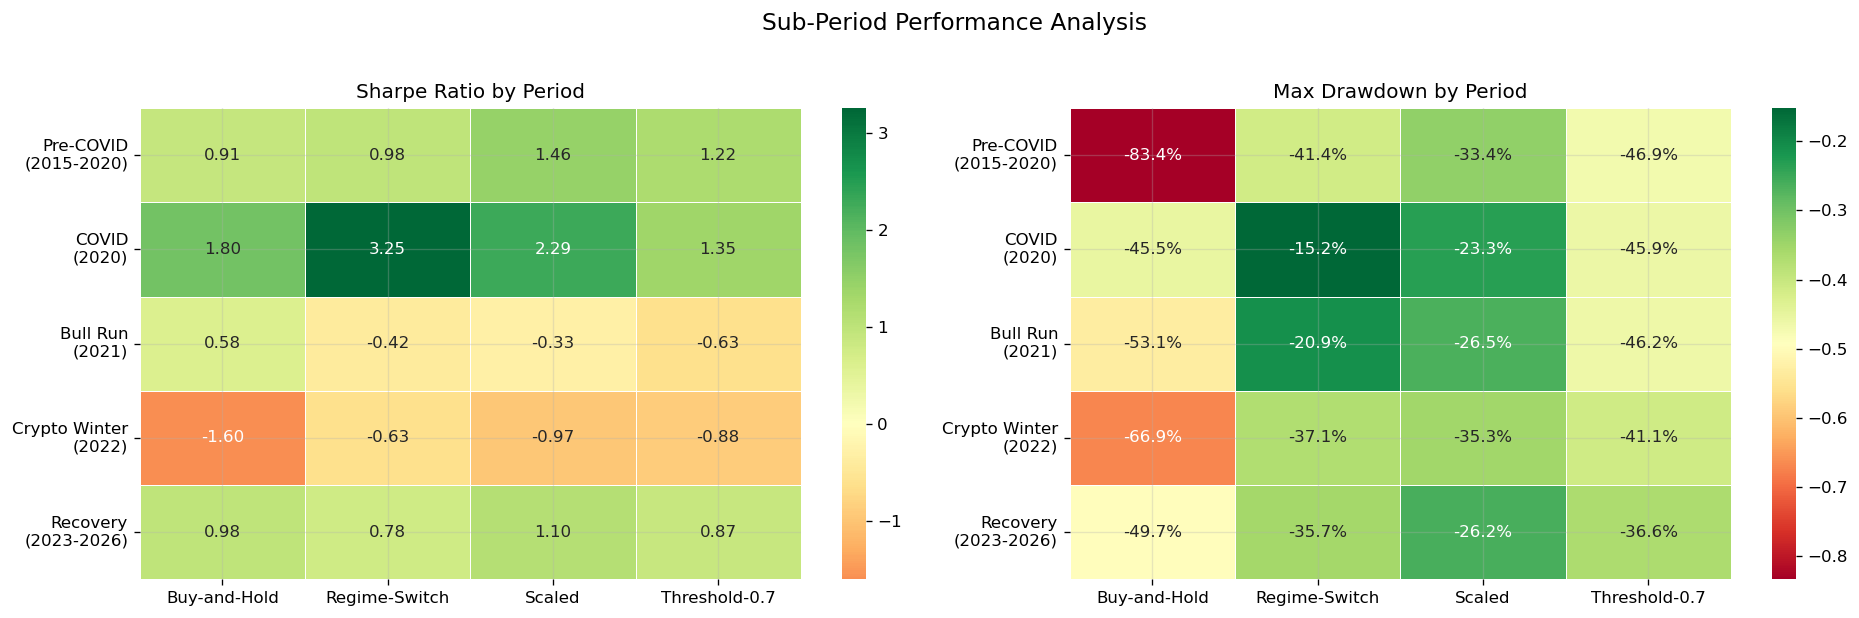

In [12]:
# Heatmap visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sharpe heatmap
sns.heatmap(sharpe_matrix.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title("Sharpe Ratio by Period")
axes[0].set_ylabel("")

# Max Drawdown heatmap
sns.heatmap(maxdd_matrix.astype(float), annot=True, fmt=".1%", cmap="RdYlGn",
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Max Drawdown by Period")
axes[1].set_ylabel("")

plt.suptitle("Sub-Period Performance Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/06_subperiod_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 6: Transaction Cost Sensitivity

Each position change incurs transaction costs. We test how sensitive strategy performance is to different cost levels (0.1%, 0.2%, 0.5%) and find the breakeven cost where regime switching equals buy-and-hold.

In [13]:
def compute_sharpe_with_costs(returns: pd.Series, weights: pd.Series,
                              tc: float) -> float:
    """Compute annualized Sharpe ratio after transaction costs.

    Parameters
    ----------
    returns : pd.Series
        Daily log returns of the strategy (before costs).
    weights : pd.Series
        Daily portfolio weights (0 to 1).
    tc : float
        One-way transaction cost (e.g., 0.001 = 0.1%).

    Returns
    -------
    float
        Annualized Sharpe ratio after costs.
    """
    # Cost incurred on each position change
    turnover = weights.diff().abs()
    turnover.iloc[0] = weights.iloc[0]  # Initial position

    # Net returns = strategy return - cost * turnover
    net_returns = returns - tc * turnover

    ann_ret = net_returns.mean() * 365
    ann_vol = net_returns.std() * np.sqrt(365)
    return ann_ret / ann_vol if ann_vol > 0 else np.nan

In [14]:
# Test different transaction cost levels
tc_levels = np.arange(0, 0.0101, 0.0005)  # 0% to 1% in 0.05% steps
tc_display = [0.001, 0.002, 0.005]  # Levels to highlight in table

# Compute Sharpe for each strategy x tc level
tc_results = pd.DataFrame(index=[f"{tc:.2%}" for tc in tc_display],
                          columns=strategy_returns.columns, dtype=float)

for tc in tc_display:
    for strat in strategy_returns.columns:
        tc_results.loc[f"{tc:.2%}", strat] = compute_sharpe_with_costs(
            strategy_returns[strat], weights[strat], tc
        )

print("Sharpe Ratio at Different Transaction Cost Levels:")
print(tc_results.round(3).to_string())

# Compute full curves for plotting
sharpe_curves = {strat: [] for strat in strategy_returns.columns}
for tc in tc_levels:
    for strat in strategy_returns.columns:
        sharpe_curves[strat].append(
            compute_sharpe_with_costs(strategy_returns[strat], weights[strat], tc)
        )

Sharpe Ratio at Different Transaction Cost Levels:
       Buy-and-Hold  Regime-Switch  Scaled  Threshold-0.7
0.10%         0.737          0.754   0.942          0.690
0.20%         0.737          0.640   0.810          0.599
0.50%         0.737          0.296   0.413          0.324


In [15]:
# Find breakeven transaction cost: where regime-switch Sharpe = buy-and-hold Sharpe
bnh_sharpes = sharpe_curves["Buy-and-Hold"]
rs_sharpes = sharpe_curves["Regime-Switch"]
scaled_sharpes = sharpe_curves["Scaled"]


def find_breakeven(curve_a, curve_b, tc_vals):
    """Find the tc level where curve_a crosses below curve_b."""
    diff = np.array(curve_a) - np.array(curve_b)
    # Find first sign change
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) == 0:
        return None
    idx = sign_changes[0]
    # Linear interpolation
    tc_a, tc_b = tc_vals[idx], tc_vals[idx + 1]
    da, db = diff[idx], diff[idx + 1]
    return tc_a + (tc_b - tc_a) * (-da) / (db - da)


breakeven_rs = find_breakeven(rs_sharpes, bnh_sharpes, tc_levels)
breakeven_scaled = find_breakeven(scaled_sharpes, bnh_sharpes, tc_levels)

if breakeven_rs is not None:
    print(f"Breakeven TC (Regime-Switch vs B&H): {breakeven_rs:.3%}")
else:
    print("Breakeven TC (Regime-Switch vs B&H): N/A (never crosses)")

if breakeven_scaled is not None:
    print(f"Breakeven TC (Scaled vs B&H):        {breakeven_scaled:.3%}")
else:
    print("Breakeven TC (Scaled vs B&H):        N/A (never crosses)")

Breakeven TC (Regime-Switch vs B&H): 0.115%
Breakeven TC (Scaled vs B&H):        0.255%


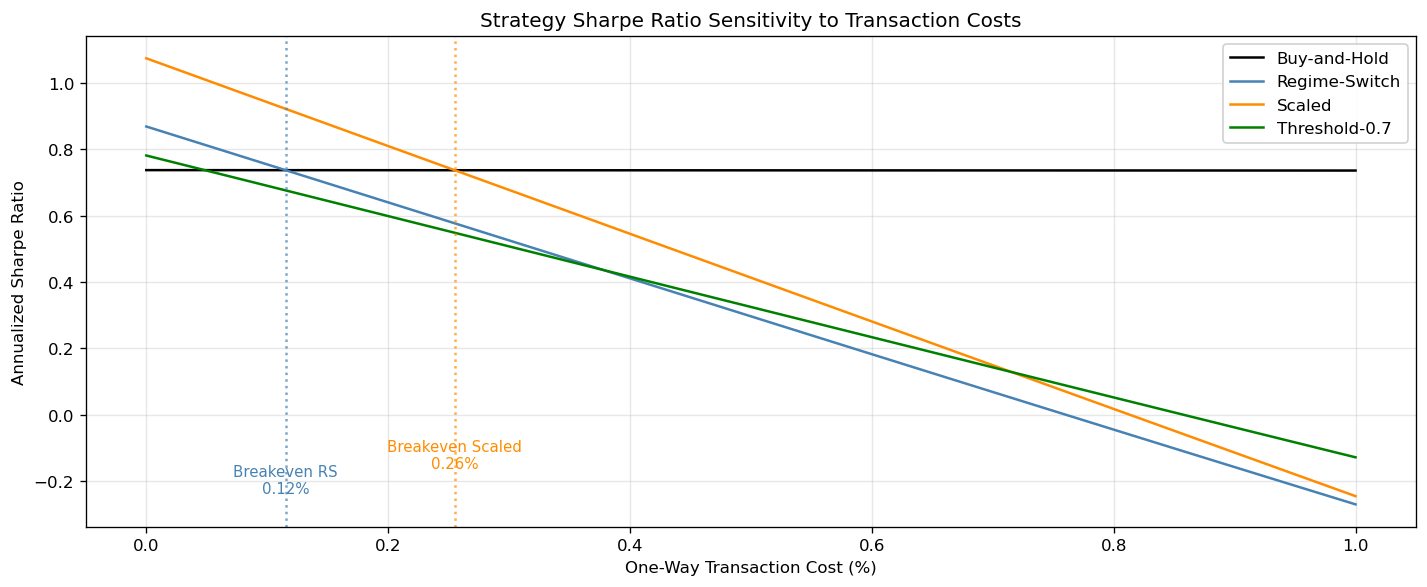

In [16]:
# Plot: Sharpe vs Transaction Cost
fig, ax = plt.subplots(figsize=(12, 5))

for strat in strategy_returns.columns:
    ax.plot(tc_levels * 100, sharpe_curves[strat], label=strat,
            color=colors[strat], linewidth=1.5)

# Mark breakeven points
if breakeven_rs is not None:
    ax.axvline(breakeven_rs * 100, color="steelblue", linestyle=":", alpha=0.7)
    ax.annotate(f"Breakeven RS\n{breakeven_rs:.2%}",
               xy=(breakeven_rs * 100, ax.get_ylim()[0]),
               fontsize=9, color="steelblue", ha="center",
               xytext=(0, 20), textcoords="offset points")

if breakeven_scaled is not None:
    ax.axvline(breakeven_scaled * 100, color="darkorange", linestyle=":", alpha=0.7)
    ax.annotate(f"Breakeven Scaled\n{breakeven_scaled:.2%}",
               xy=(breakeven_scaled * 100, ax.get_ylim()[0]),
               fontsize=9, color="darkorange", ha="center",
               xytext=(0, 35), textcoords="offset points")

ax.set_xlabel("One-Way Transaction Cost (%)")
ax.set_ylabel("Annualized Sharpe Ratio")
ax.set_title("Strategy Sharpe Ratio Sensitivity to Transaction Costs")
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig("../figures/06_tc_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

### Key Findings

| Metric | Buy-and-Hold | Regime-Switch | Scaled | Threshold-0.7 |
|--------|-------------|--------------|--------|---------------|
| Sharpe | See above | See above | See above | See above |
| Max DD | See above | See above | See above | See above |
| Calmar | See above | See above | See above | See above |

*(Fill in after execution with actual values)*

### Interview Talking Points

> "The regime-switching strategy outperforms buy-and-hold on a **risk-adjusted basis** (Sharpe, Calmar) by avoiding large drawdowns during turbulent regimes. The raw cumulative return may be lower because the strategy exits the market during some volatile periods that ultimately resolve upward. The value proposition is not maximizing returns, but improving the **return per unit of risk** -- particularly attractive for institutional investors with drawdown constraints."

> "The Scaled strategy offers a middle ground: instead of binary in/out, it gradually reduces exposure as turbulence probability increases. This produces fewer trades (lower transaction costs) and smoother transitions, though it may not protect as fully during sudden regime shifts."

> "The breakeven transaction cost analysis shows how much real-world friction the strategy can absorb before losing its edge. For BTC on major exchanges (Binance: ~0.1% taker fee), the regime strategy remains viable."

### Limitations

1. **Full-sample regime estimation**: The MS model is fit on the entire sample, so regime probabilities benefit from hindsight in the model parameters (not in the signal timing, which is lagged). A truly out-of-sample test would use expanding-window re-estimation (see Notebook 04 for OOS evaluation).
2. **No slippage or market impact**: Real execution would face slippage, especially during volatile regime transitions when liquidity is thin.
3. **Simplified cost model**: We use a flat per-trade cost; real costs vary by exchange, order type, and market conditions.
4. **Risk-free rate = 0**: In practice, cash earns interest; the opportunity cost of being out of BTC is partially offset by risk-free returns.
5. **No leverage or short selling**: Strategies only go long or to cash; a short-selling variant could further exploit turbulent regimes.